# Semi-Supervised MNIST Classification — Full Pipeline (v2)

**Flow:**
- Stage 1: SimCLR (Modified ResNet-18) → Label Propagation (+ confidence filter)
- Stage 2: cVAE pretraining (β annealing)
- Stage 3: GAN main loop (frozen SimCLR + EfficientNet features projected → concat, trainable ResNet + SpectralNorm)
- Inference: SWA-D + TTA (5 aug views → softmax avg)

**改善点 (v2):**
- 全フェーズで train/val 分割 (labeled 500 → 400 train / 100 val、stratified)
- test 10000件は最後の1回のみ使用
- LP: lp_alpha 0.99→0.92、Top-K per class + 信頼度フロア (curriculum動的閾値)
- SimCLR: Gradient Accumulation (実効バッチ ×4) + val kNN acc
- FixMatch式 Weak/Strong分離: 疑似ラベル生成は weak aug、学習は strong aug
- Stage 3毎エポック: train loss / val acc をログ

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torch.optim.swa_utils import AveragedModel, SWALR
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as tvm
import numpy as np
import random
import math
import copy
import os
from dataclasses import dataclass
from typing import Optional, Tuple, List
from tqdm.auto import tqdm
import kornia.augmentation as K
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


In [2]:
@dataclass
class Config:
    # Data
    n_labeled:        int   = 500
    n_unlabeled:      int   = 3000
    n_classes:        int   = 10
    img_size:         int   = 32
    val_ratio:        float = 0.2   # labeled を 80/20 で train/val 分割

    # Stage 1: SimCLR
    simclr_epochs:    int   = 200
    simclr_lr:        float = 3e-4
    simclr_batch:     int   = 256
    simclr_accum:     int   = 4     # gradient accumulation → 実効バッチ 1024
    simclr_feat:      int   = 256   # WRN-28-4: 64*4=256
    simclr_proj:      int   = 128
    simclr_temp:      float = 0.5

    # WideResNet
    wrn_depth:        int   = 28
    wrn_width:        int   = 4          # feat_dim = 64 * width = 256

    # Stage 1b: Label Propagation
    lp_k:             int   = 15
    lp_alpha:         float = 0.92   # 0.99→0.92: ラベルの影響力を残す
    lp_iters:         int   = 60
    # Dynamic threshold: Top-K per class (カリキュラム方式)
    lp_topk_init:     int   = 20    # 初回: 各クラス上位20件
    lp_topk_max:      int   = 50    # 最大: 各クラス上位50件
    lp_conf_floor:    float = 0.70  # Top-Kでも最低この信頼度は必要

    # Stage 2: cVAE
    cvae_epochs:      int   = 100
    cvae_lr:          float = 1e-3
    cvae_batch:       int   = 128
    latent_dim:       int   = 64
    beta_start:       float = 1.0   # 4.0→1.0: KL支配でグレー崩壊するのを防ぐ
    beta_end:         float = 0.5
    lambda_percep:    float = 0.1

    # Stage 3: GAN
    gan_epochs:       int   = 300
    gan_lr_d:         float = 2e-4
    gan_lr_g:         float = 2e-4
    gan_lr_cls:       float = 1e-4
    gan_batch:        int   = 128
    fixmatch_thresh: float = 0.95
    fixmatch_temp:   float = 0.5

    # Loss weights
    lam_cls:          float = 1.0
    lam_gen:          float = 0.5
    lam_sc:           float = 0.3
    lam_pseudo:       float = 0.5
    lam_fm:           float = 1.0

    warmup_gen:       int   = 20
    warmup_sc:        int   = 30
    pseudo_refresh:   int   = 20   # epoch間隔でLP再計算 & topk増加

    # EMA / SWA
    ema_decay:        float = 0.999
    swa_start:        float = 0.75

    # ADA
    ada_target:       float = 0.6
    ada_interval:     int   = 4

    # Feature dims
    simclr_comp:      int   = 128
    eff_comp:         int   = 128
    train_feat:       int   = 256   # WRN-28-4: 64*4=256
    disc_hidden:      int   = 512   # 128+128+256=512

    # Logging
    log_interval:     int   = 10   # epoch間隔でval acc表示

    device: str = DEVICE

cfg = Config()

In [3]:
class MNISTSemiDataset(Dataset):
    def __init__(self, images: torch.Tensor, labels: torch.Tensor):
        self.images = images
        self.labels = labels
    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.images[i], self.labels[i]

def load_mnist(cfg: Config):
    """
    MNIST を読み込み、labeled を stratified に train_l / val_l へ分割。
    test は返すが最後の評価にのみ使う。
    """
    tf = T.Compose([
        T.Resize(cfg.img_size),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1)),
    ])
    full_train = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf)
    test_ds    = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf)

    per_class = cfg.n_labeled // cfg.n_classes
    labeled_idx, unlabeled_idx = [], []
    counts = {c: 0 for c in range(cfg.n_classes)}
    perm = torch.randperm(len(full_train)).tolist()
    for i in perm:
        _, lbl = full_train[i]
        if counts[lbl] < per_class:
            labeled_idx.append(i); counts[lbl] += 1
        elif len(unlabeled_idx) < cfg.n_unlabeled:
            unlabeled_idx.append(i)
        if len(labeled_idx) == cfg.n_labeled and len(unlabeled_idx) == cfg.n_unlabeled:
            break

    def collect(ds, idx, mask_label=False):
        imgs, lbls = [], []
        for i in idx:
            im, lb = ds[i]
            imgs.append(im)
            lbls.append(-1 if mask_label else lb)
        return torch.stack(imgs), torch.tensor(lbls)

    lx, ly = collect(full_train, labeled_idx)
    ux, _  = collect(full_train, unlabeled_idx, mask_label=True)

    # --- Stratified train/val split of labeled data ---
    val_per_class = max(1, int(per_class * cfg.val_ratio))
    train_idx, val_idx = [], []
    vcounts = {c: 0 for c in range(cfg.n_classes)}
    # shuffle within labeled
    lperm = torch.randperm(len(lx)).tolist()
    for i in lperm:
        c = ly[i].item()
        if vcounts[c] < val_per_class:
            val_idx.append(i); vcounts[c] += 1
        else:
            train_idx.append(i)

    lx_train, ly_train = lx[train_idx], ly[train_idx]
    lx_val,   ly_val   = lx[val_idx],   ly[val_idx]

    # test
    test_imgs = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
    test_lbls = torch.tensor([test_ds[i][1] for i in range(len(test_ds))])

    print(f"Labeled train: {len(lx_train)}, Labeled val: {len(lx_val)}, "
          f"Unlabeled: {len(ux)}, Test: {len(test_imgs)}")
    return lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls

lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls = load_mnist(cfg)

Labeled train: 80, Labeled val: 20, Unlabeled: 1000, Test: 10000


In [4]:
# FixMatch 式の分離:
#   weak   : crop + hflip のみ → 疑似ラベルの「決定」に使用
#   strong : DiffAugment       → 学習時に使用
#   disc   : ADA確率で strong  → D の real/fake に使用

# ---------- DiffAugment ----------
def rand_brightness(x):
    f = torch.empty(x.size(0),1,1,1,device=x.device).uniform_(0.5,1.5)
    return (x*f).clamp(0,1)
def rand_saturation(x):
    g = x.mean(dim=1,keepdim=True)
    f = torch.empty(x.size(0),1,1,1,device=x.device).uniform_(0.5,1.5)
    return torch.lerp(g,x,f).clamp(0,1)
def rand_contrast(x):
    m = x.mean(dim=(1,2,3),keepdim=True)
    f = torch.empty(x.size(0),1,1,1,device=x.device).uniform_(0.5,1.5)
    return torch.lerp(m,x,f).clamp(0,1)
def rand_translation(x, ratio=0.125):
    B,C,H,W = x.shape
    sh=int(H*ratio); sw=int(W*ratio)
    tx=torch.randint(-sw,sw+1,(B,)); ty=torch.randint(-sh,sh+1,(B,))
    theta=torch.zeros(B,2,3,device=x.device)
    theta[:,0,0]=1; theta[:,1,1]=1
    theta[:,0,2]=tx.float()/W*2; theta[:,1,2]=ty.float()/H*2
    grid=F.affine_grid(theta,x.shape,align_corners=False)
    return F.grid_sample(x,grid,align_corners=False,padding_mode="reflection")
def rand_cutout(x, ratio=0.5):
    B,C,H,W=x.shape; ch=int(H*ratio); cw=int(W*ratio)
    out=x.clone()
    for i in range(B):
        t=random.randint(0,H-ch); l=random.randint(0,W-cw)
        out[i,:,t:t+ch,l:l+cw]=0
    return out

def rand_rotation(x, max_deg=15):
    """
    ★ 修正: Python ループ + TF.rotate → grid_sample による完全ベクトル化。
    旧実装は 128枚 × GPU sync で ~1.5秒/呼び出しかかっていた。
    新実装は単一の F.affine_grid + F.grid_sample で完結。
    """
    B, C, H, W = x.shape
    rad = torch.empty(B, device=x.device).uniform_(
        -max_deg * math.pi / 180, max_deg * math.pi / 180)
    cos_a, sin_a = rad.cos(), rad.sin()
    theta = torch.zeros(B, 2, 3, device=x.device)
    theta[:, 0, 0] =  cos_a; theta[:, 0, 1] = -sin_a
    theta[:, 1, 0] =  sin_a; theta[:, 1, 1] =  cos_a
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, align_corners=False, padding_mode="reflection")

def diff_augment(x, policy="color,translation,cutout,rotation"):
    for p in policy.split(","):
        p=p.strip()
        if   p=="color":       x = rand_contrast(rand_saturation(rand_brightness(x)))
        elif p=="translation": x = rand_translation(x)
        elif p=="cutout":      x = rand_cutout(x)
        elif p=="rotation":    x = rand_rotation(x)
    return x.clamp(0,1)

# ---------- Weak augment (FixMatch 決定用) ----------
# ★ 修正: GPU tensor をループで処理すると CUDA sync が batch_size 回発生する。
#         CPU に移してから変換→まとめて GPU 転送する方が大幅に速い。
_weak_gpu = K.AugmentationSequential(
    K.RandomCrop((32, 32), padding=4),
    K.RandomHorizontalFlip(),
    data_keys=["input"])
def weak_aug(x: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        return _weak_gpu(x)

# ---------- Mixup / CutMix ----------
def mixup(x,y,alpha=0.4):
    lam=np.random.beta(alpha,alpha)
    idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam

def cutmix(x,y,alpha=1.0):
    lam=np.random.beta(alpha,alpha)
    B,C,H,W=x.shape
    cr=math.sqrt(1-lam); ch=int(H*cr); cw=int(W*cr)
    cx=random.randint(0,W); cy=random.randint(0,H)
    x1=max(0,cx-cw//2); x2=min(W,cx+cw//2)
    y1=max(0,cy-ch//2); y2=min(H,cy+ch//2)
    lam=1-(x2-x1)*(y2-y1)/(W*H)
    idx=torch.randperm(B,device=x.device)
    out=x.clone(); out[:,:,y1:y2,x1:x2]=x[idx,:,y1:y2,x1:x2]
    return out,y,y[idx],lam

def mix_criterion(crit,pred,ya,yb,lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)

# ---------- ADA ----------
class ADAController:
    def __init__(self, target=0.6, interval=4, speed=1e-3):
        self.p=0.0; self.target=target
        self.interval=interval; self.speed=speed
        self._step=0; self._signs=[]
    def update(self, fake_logits_on_real: torch.Tensor):
        """
        fake_logits_on_real: D の fake チャネル (class n_classes) の実画像への出力。
        値が負 → D が「本物」と判断。(-logit > 0) の割合で追跡。
        """
        self._signs.append((-fake_logits_on_real > 0).float().mean().item())
        self._step+=1
        if self._step%self.interval==0:
            rt=np.mean(self._signs[-self.interval:])
            adj=np.sign(rt-self.target)*self.speed*self.interval
            self.p=float(np.clip(self.p+adj,0,1))
    def apply(self, x):
        return diff_augment(x) if random.random()<self.p else x

ada = ADAController(target=cfg.ada_target, interval=cfg.ada_interval)

# ---------- Curriculum classifier view ----------
def get_cls_view(x, y, epoch, cfg):
    x = weak_aug(x)
    if epoch < 60:
        return x, y, y, 1.0
    if epoch < 120:
        if random.random() < 0.5:
            return mixup(x, y)
        return x, y, y, 1.0
    if random.random() < 0.5:
        fn = mixup if random.random()<0.5 else cutmix
        return fn(x, y)
    return x, y, y, 1.0


In [5]:
def sn_linear(i, o, **kw): return spectral_norm(nn.Linear(i, o, **kw))

# ================================================================
# WideResNet (CIFAR スタイル 32x32 対応)
# WRN-28-4: depth=28, width=4 → feat_dim = 64*4 = 256
# ================================================================
class WideResNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0, use_sn=False):
        super().__init__()
        W = spectral_norm if use_sn else (lambda m: m)
        self.bn1   = nn.BatchNorm2d(in_ch)
        self.conv1 = W(nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False))
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.drop  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.conv2 = W(nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False))
        self.skip  = (W(nn.Conv2d(in_ch, out_ch, 1, stride, bias=False))
                      if stride != 1 or in_ch != out_ch else nn.Identity())

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x), inplace=True))
        out = self.conv2(F.relu(self.bn2(self.drop(out)), inplace=True))
        return out + self.skip(x)


class WideResNet(nn.Module):
    """
    WRN-depth-width for 32x32 inputs.
      depth=28, width=4, dropout=0.0  → SimCLR backbone
      depth=28, width=4, dropout=0.3, use_sn=True → D trainable backbone
    feat_dim = 64 * width  (WRN-28-4: 256)
    """
    def __init__(self, depth=28, width=4, dropout=0.0, use_sn=False):
        super().__init__()
        assert (depth - 4) % 6 == 0, "depth must satisfy (depth-4)%6==0"
        n  = (depth - 4) // 6
        k  = width
        ch = [16, 16*k, 32*k, 64*k]
        W  = spectral_norm if use_sn else (lambda m: m)
        self.conv0  = W(nn.Conv2d(3, ch[0], 3, 1, 1, bias=False))
        self.layer1 = self._make(n, ch[0], ch[1], 1, dropout, use_sn)
        self.layer2 = self._make(n, ch[1], ch[2], 2, dropout, use_sn)
        self.layer3 = self._make(n, ch[2], ch[3], 2, dropout, use_sn)
        self.bn     = nn.BatchNorm2d(ch[3])
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.feat_dim = ch[3]  # = 64 * width

    def _make(self, n, ic, oc, stride, dropout, use_sn):
        layers = [WideResNetBlock(ic, oc, stride, dropout, use_sn)]
        for _ in range(n - 1):
            layers.append(WideResNetBlock(oc, oc, 1, dropout, use_sn))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv0(x)
        out = self.layer3(self.layer2(self.layer1(out)))
        return self.pool(F.relu(self.bn(out), inplace=True)).flatten(1)


class SimCLR(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone  = WideResNet(cfg.wrn_depth, cfg.wrn_width, dropout=0.0)
        feat = self.backbone.feat_dim  # 256 for WRN-28-4
        self.projector = nn.Sequential(
            nn.Linear(feat, feat), nn.ReLU(True),
            nn.Linear(feat, cfg.simclr_proj))

    def encode(self, x): return self.backbone(x)

    def forward(self, x):
        return F.normalize(self.projector(self.backbone(x)), dim=-1)


class EfficientNetB0Features(nn.Module):
    def __init__(self):
        super().__init__()
        eff = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        self.features  = eff.features
        self.pool      = eff.avgpool
        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    def forward(self, x):
        return self.pool(self.features(self.normalize(x))).flatten(1)


class CVAEEncoder(nn.Module):
    def __init__(self, img_ch=3, img_size=32, n_classes=10, latent_dim=64):
        super().__init__()
        self.embed = nn.Embedding(n_classes, 16)
        self.net   = nn.Sequential(
            nn.Conv2d(img_ch+16, 64,  4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,  128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Flatten())
        self.fc_mu     = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

    def forward(self, x, y):
        e = self.embed(y)[:, :, None, None].expand(-1, -1, x.size(2), x.size(3))
        h = self.net(torch.cat([x, e], 1))
        return self.fc_mu(h), self.fc_logvar(h)


class Generator(nn.Module):
    """
    グレー背景修正:
      1. 最終活性化: Tanh → Sigmoid  (出力 [0,1], (out+1)/2 不要)
      2. 最終 Conv bias を +1.5 初期化 → sigmoid(1.5)≈0.82 (白寄りスタート)
      3. 全 ConvTranspose2d に SpectralNorm
    """
    def __init__(self, latent_dim=64, n_classes=10, img_ch=3, img_size=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_size   = img_size
        self.embed = nn.Embedding(n_classes, 64)
        self.fc    = nn.Linear(latent_dim + 64, 256 * 4 * 4)
        final_conv = nn.Conv2d(32, img_ch, 3, 1, 1)
        nn.init.constant_(final_conv.bias, 1.5)  # sigmoid(1.5)≈0.82
        self.net = nn.Sequential(
            nn.BatchNorm2d(256),
            spectral_norm(nn.ConvTranspose2d(256, 128, 4, 2, 1)),
            nn.BatchNorm2d(128), nn.ReLU(True),
            spectral_norm(nn.ConvTranspose2d(128, 64, 4, 2, 1)),
            nn.BatchNorm2d(64),  nn.ReLU(True),
            spectral_norm(nn.ConvTranspose2d(64, 32, 4, 2, 1)),
            nn.BatchNorm2d(32),  nn.ReLU(True),
            spectral_norm(final_conv),
            nn.Sigmoid(),  # ← Tanh から変更; 出力は直接 [0,1]
        )

    def forward(self, z, y):
        e   = self.embed(y)
        h   = F.relu(self.fc(torch.cat([z, e], 1)), inplace=True).view(-1, 256, 4, 4)
        out = self.net(h)
        if out.size(-1) != self.img_size:
            out = F.interpolate(out, self.img_size, mode="bilinear", align_corners=False)
        return out  # [0,1]; (out+1)/2 不要


class Discriminator(nn.Module):
    """
    入力特徴: 凍結 SimCLR WRN-28-4 (256→comp128)
            + 凍結 EfficientNet-B0 (1280→comp128)
            + 訓練可能 WRN-28-4 (256, SN+dropout=0.3)
    合計: 128+128+256 = 512 = disc_hidden
    """
    def __init__(self, cfg, simclr_backbone, eff_backbone):
        super().__init__()
        self.simclr_backbone = simclr_backbone
        self.eff_backbone    = eff_backbone
        for p in self.simclr_backbone.parameters(): p.requires_grad_(False)
        for p in self.eff_backbone.parameters():    p.requires_grad_(False)

        self.simclr_comp = nn.Sequential(
            sn_linear(cfg.simclr_feat, cfg.simclr_comp), nn.LeakyReLU(0.2, True))
        self.eff_comp    = nn.Sequential(
            sn_linear(1280, cfg.eff_comp), nn.LeakyReLU(0.2, True))

        # 訓練可能バックボーン: WRN-28-4 + SpectralNorm + dropout=0.3
        self.train_backbone = WideResNet(cfg.wrn_depth, cfg.wrn_width,
                                         dropout=0.3, use_sn=True)

        total = cfg.simclr_comp + cfg.eff_comp + cfg.train_feat  # 128+128+256=512
        self.shared   = nn.Sequential(
            sn_linear(total, cfg.disc_hidden), nn.LeakyReLU(0.2, True),
            sn_linear(cfg.disc_hidden, cfg.simclr_proj))
        self.cls_head = sn_linear(cfg.simclr_proj, cfg.n_classes + 1)  # 11クラス
        self.embed    = nn.Embedding(cfg.n_classes, cfg.simclr_proj)   # projection D

    def features(self, x):
        with torch.no_grad():
            fs = self.simclr_backbone(x)
            fe = self.eff_backbone(x)
        return self.shared(torch.cat(
            [self.simclr_comp(fs), self.eff_comp(fe), self.train_backbone(x)], 1))

    def forward(self, x, y=None):
        h      = self.features(x)
        logits = self.cls_head(h)
        if y is not None:
            proj = (h * self.embed(y)).sum(1)
            logits[torch.arange(len(y)), y] += proj
        return logits  # (B, n_classes+1)


In [6]:
class NTXentLoss(nn.Module):
    def __init__(self,temperature=0.5): super().__init__(); self.T=temperature
    def forward(self,z1,z2):
        N=z1.size(0); z=torch.cat([z1,z2],0)
        sim=F.cosine_similarity(z.unsqueeze(1),z.unsqueeze(0),dim=-1)/self.T
        mask=torch.eye(2*N,device=z.device).bool(); sim.masked_fill_(mask,-1e9)
        tgt=torch.arange(N,device=z.device); tgt=torch.cat([tgt+N,tgt])
        return F.cross_entropy(sim,tgt)

class SupConLoss(nn.Module):
    def __init__(self,temperature=0.07): super().__init__(); self.T=temperature
    def forward(self,features,labels):
        B=features.size(0); f=F.normalize(features.view(2*B,-1),dim=-1)
        sim=torch.matmul(f,f.T)/self.T
        mask=torch.eye(2*B,device=f.device).bool()
        lbl=labels.repeat_interleave(2)
        pos_mask=((lbl.unsqueeze(0)==lbl.unsqueeze(1))&~mask).float()
        log_prob = sim - torch.logsumexp(
            sim.masked_fill(mask, -1e9), dim=1, keepdim=True)

        loss = -(pos_mask * log_prob).sum(1) / pos_mask.sum(1).clamp(min=1)
        return loss.mean()

class HingeLoss:
    @staticmethod
    def d_real(l): return F.relu(1.-l).mean()
    @staticmethod
    def d_fake(l): return F.relu(1.+l).mean()
    @staticmethod
    def g(l):      return -l.mean()

def feature_matching_loss(rf,ff): return F.l1_loss(ff,rf.detach())
def soft_kl_loss(logits,soft):
    return F.kl_div(F.log_softmax(logits,dim=-1),soft.clamp(1e-6),reduction="batchmean")
def vae_loss(recon,x,mu,logvar,beta,perc_fn=None,perc_w=0.):
    # BCE: MNIST は二値画像のため L1 よりグレー崩壊防止に有効
    rl=F.binary_cross_entropy(recon, x, reduction='mean')
    kl=-0.5*(1+logvar-mu.pow(2)-logvar.exp()).mean()
    loss=rl+beta*kl
    if perc_fn and perc_w>0: loss+=perc_w*perc_fn(recon,x)
    return loss,rl,kl

In [7]:
@torch.no_grad()
def knn_accuracy(model, db_imgs, db_lbls, query_imgs, query_lbls,
                 k=5, batch=256, device=DEVICE, loo=False):
    model.eval()
    def extract(imgs):
        fs = []
        for i in range(0, len(imgs), batch):
            fs.append(model.encode(imgs[i:i+batch].to(device)).cpu())
        return torch.cat(fs, 0)
    f_db    = F.normalize(extract(db_imgs),    dim=-1)
    f_query = F.normalize(extract(query_imgs), dim=-1)
    sim = f_query @ f_db.T
    if loo: sim.fill_diagonal_(-1e9)
    preds, _ = db_lbls[sim.topk(k, dim=1).indices].mode(dim=1)
    return (preds == query_lbls).float().mean().item()

@torch.no_grad()
def simclr_val_loss(model, lx_val, crit, device):
    model.eval()
    x = lx_val.to(device)
    loss = crit(model(diff_augment(x)), model(diff_augment(x))).item()
    model.train()
    return loss

def train_simclr(cfg, lx_train, lx_val, ly_train, ly_val, ux):
    all_imgs = torch.cat([lx_train, ux], 0)
    loader   = DataLoader(TensorDataset(all_imgs), batch_size=cfg.simclr_batch,
                          shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    model = SimCLR(cfg).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.simclr_lr, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.simclr_epochs)
    crit  = NTXentLoss(cfg.simclr_temp)

    os.makedirs("models/sgan", exist_ok=True)
    save_path = "models/sgan/simclr_best.pth"
    if os.path.exists(save_path):
        tqdm.write(f"Loading SimCLR from {save_path}")
        model.load_state_dict(torch.load(save_path, map_location=cfg.device,
                                         weights_only=True))
        return model

    best_val_acc = 0.0; A = cfg.simclr_accum
    for epoch in range(cfg.simclr_epochs):
        model.train(); total = 0.0; opt.zero_grad()

        step_bar = tqdm(loader, desc=f"Epoch {epoch+1}", position=0, leave=True, unit="batch")
        for step, (x,) in enumerate(step_bar):
            x = x.to(cfg.device)
            loss = crit(model(diff_augment(x)), model(diff_augment(x))) / A
            loss.backward()
            if (step + 1) % A == 0: opt.step(); opt.zero_grad()
            total += loss.item() * A

            step_bar.set_postfix(loss=f"{loss.item()*A:.4f}")
        if len(loader) % A != 0: opt.step(); opt.zero_grad()  # 端数 flush
        sched.step()
        avg = total / len(loader)

        if (epoch + 1) % 20 == 0:
            vl  = simclr_val_loss(model, lx_val, crit, cfg.device)
            tka = knn_accuracy(model, lx_train, ly_train, lx_train, ly_train,
                               loo=True, device=cfg.device)
            vka = knn_accuracy(model, lx_train, ly_train, lx_val, ly_val,
                               device=cfg.device)
            tqdm.write(
                f"[SimCLR ep {epoch+1:03d}/{cfg.simclr_epochs}] "
                f"train_loss={avg:.4f}  val_loss={vl:.4f} | "
                f"train_kNN={tka*100:.1f}%  val_kNN={vka*100:.1f}%")
            if vka > best_val_acc:
                best_val_acc = vka
                torch.save(model.state_dict(), save_path)
                tqdm.write(f"  => [SimCLR Best] val_kNN={best_val_acc*100:.1f}%  saved.")

    model.load_state_dict(torch.load(save_path, map_location=cfg.device,
                                     weights_only=True))
    return model

print("=== Stage 1: SimCLR ===")
simclr_model = train_simclr(cfg, lx_train, lx_val, ly_train, ly_val, ux)


=== Stage 1: SimCLR ===


Epoch 1:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 4:   0%|          | 0/4 [00:00<?, ?batch/s]

...

Epoch 197:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 198:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 199:   0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 200:   0%|          | 0/4 [00:00<?, ?batch/s]

[SimCLR ep 200/200] train_loss=4.8102  val_loss=2.2846 | train_kNN=52.5%  val_kNN=55.0%


In [8]:
def label_propagation(cfg, simclr_model, lx_train, ly_train, ux,
                      refresh_count: int = 0, D_model=None):
    """
    refresh_count: 何回目の LP か (0=初回)。topk をカリキュラム的に増やす。
    動的閾値:
      - 各クラスの信頼スコア上位 topk 件を選択
      - ただし conf < lp_conf_floor のものは除外
    """
    from scipy.sparse import csr_matrix

    all_imgs=torch.cat([lx_train,ux],0).to(cfg.device)
    N_l=len(lx_train); N=len(all_imgs)
    n_refreshes=cfg.gan_epochs//cfg.pseudo_refresh

    # Curriculum topk: 初回→最終でlinear補間
    frac=min(1.0, refresh_count/(max(1,n_refreshes)))
    topk=int(cfg.lp_topk_init+(cfg.lp_topk_max-cfg.lp_topk_init)*frac)
    print(f"  [LP] refresh#{refresh_count}  α={cfg.lp_alpha}  topk={topk}/class  "
          f"conf_floor={cfg.lp_conf_floor}")

    simclr_model.eval()
    with torch.no_grad():
        feats=[]
        for i in range(0,N,256):
            feats.append(simclr_model.encode(all_imgs[i:i+256]))
        feats=torch.cat(feats,0).cpu().numpy()
    feats/=(np.linalg.norm(feats,axis=1,keepdims=True)+1e-8)

    # 初回はSimCLR only、refresh_count >= 2 以降はアンサンブル
    if refresh_count >= 2 and D_model is not None:
        D_model.eval()
        with torch.no_grad():
            d_feats = []
            for i in range(0, N, 256):
                d_feats.append(D_model.features(all_imgs[i:i+256]))
            d_feats = torch.cat(d_feats, 0).cpu().numpy()
            d_feats /= np.linalg.norm(d_feats, axis=1, keepdims=True) + 1e-8
        feats = np.concatenate([feats, d_feats], axis=1)  # 特徴を連結してcos類似度
        feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)

    # k-NN affinity
    sim=feats@feats.T; np.fill_diagonal(sim,-1)
    knn_idx=np.argsort(-sim,axis=1)[:,:cfg.lp_k]
    knn_val=np.exp(sim[np.arange(N)[:,None],knn_idx])
    rows=np.repeat(np.arange(N),cfg.lp_k); cols=knn_idx.ravel(); vals=knn_val.ravel()
    W=csr_matrix((vals,(rows,cols)),shape=(N,N)); W=(W+W.T)/2
    d=np.asarray(W.sum(1)).ravel()**-0.5
    D_mat=csr_matrix((d,(np.arange(N),np.arange(N))),shape=(N,N))
    S=(D_mat@W@D_mat).toarray().astype(np.float32)

    # Label matrix: labeled train のみ初期化
    Y=np.zeros((N,cfg.n_classes),dtype=np.float32)
    for i,lbl in enumerate(ly_train.numpy()):
        Y[i,lbl]=1.0

    F_mat=Y.copy()
    for _ in range(cfg.lp_iters):
        F_mat=cfg.lp_alpha*(S@F_mat)+(1-cfg.lp_alpha)*Y
    F_mat/=(F_mat.sum(1,keepdims=True)+1e-8)

    conf=F_mat.max(axis=1)           # (N,)
    hard=F_mat.argmax(axis=1)        # (N,)

    # --- Top-K per class selection (unlabeled 部分のみ) ---
    ul_F=F_mat[N_l:]                 # (N_u, n_classes)
    ul_conf=conf[N_l:]
    ul_hard=hard[N_l:]
    confident_ul=np.zeros(len(ux),dtype=bool)

    for c in range(cfg.n_classes):
        cls_idx = np.where(ul_hard == c)[0]  # クラスcと予測されたインデックスのみ
        if len(cls_idx) == 0: continue
        # そのクラス内で信頼度上位topk件を選択
        sorted_idx = cls_idx[np.argsort(-ul_conf[cls_idx])]
        for i in sorted_idx[:topk]:
            if ul_conf[i] >= cfg.lp_conf_floor:
                confident_ul[i] = True

    soft_all=torch.tensor(F_mat,dtype=torch.float32)
    # labeled部分は全信頼
    confident_mask=np.concatenate([np.ones(N_l,dtype=bool),confident_ul])

    n_conf_ul=confident_ul.sum()
    print(f"  [LP] confident unlabeled: {n_conf_ul}/{len(ux)}  "
          f"total (incl. labeled): {confident_mask.sum()}/{N}")
    return soft_all, confident_mask, hard

print("\n=== Stage 1b: Label Propagation ===")
soft_labels,lp_mask,lp_hard=label_propagation(cfg,simclr_model,lx_train,ly_train,ux,refresh_count=0)


=== Stage 1b: Label Propagation ===
  [LP] refresh#0  α=0.92  topk=20/class  conf_floor=0.7
  [LP] confident unlabeled: 20/1000  total (incl. labeled): 100/1080


In [9]:
@torch.no_grad()
def cvae_val_metrics(enc, gen, lx_val, ly_val, beta, simclr_ref, cfg):
    enc.eval(); gen.eval(); simclr_ref.eval()
    x, y = lx_val.to(cfg.device), ly_val.to(cfg.device)
    mu, logvar = enc(x, y)
    z     = mu + (0.5 * logvar).exp() * torch.randn_like(mu)
    recon = gen(z, y)
    fr = simclr_ref.encode(x); fp = simclr_ref.encode(recon)
    perc  = F.l1_loss(fp, fr)
    rl    = F.binary_cross_entropy(recon, x, reduction='mean')
    kl    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
    total = rl + beta * kl + cfg.lambda_percep * perc
    enc.train(); gen.train()
    return total.item(), rl.item()

def train_cvae(cfg, simclr_model, lx_train, ly_train, lx_val, ly_val):
    ds     = TensorDataset(lx_train, ly_train)
    # batch_size をデータ数に合わせて自動調整（少量データでもバッチが作れるように）
    _cvae_bs = min(cfg.cvae_batch, len(lx_train))
    loader = DataLoader(ds, batch_size=_cvae_bs, shuffle=True, drop_last=False)
    enc = CVAEEncoder(3, cfg.img_size, cfg.n_classes, cfg.latent_dim).to(cfg.device)
    gen = Generator(cfg.latent_dim, cfg.n_classes, 3, cfg.img_size).to(cfg.device)
    opt   = torch.optim.Adam(list(enc.parameters()) + list(gen.parameters()),
                             lr=cfg.cvae_lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cvae_epochs)
    simclr_model.eval()

    def perceptual(recon, real):
        with torch.no_grad():
            return F.l1_loss(simclr_model.encode(recon), simclr_model.encode(real))

    os.makedirs("models/sgan", exist_ok=True)
    sp_enc, sp_gen = "models/sgan/cvae_enc_best.pth", "models/sgan/cvae_gen_best.pth"
    if os.path.exists(sp_enc) and os.path.exists(sp_gen):
        tqdm.write("Loading cVAE from checkpoint")
        enc.load_state_dict(torch.load(sp_enc, map_location=cfg.device, weights_only=True))
        gen.load_state_dict(torch.load(sp_gen, map_location=cfg.device, weights_only=True))
        return enc, gen

    if len(loader) == 0:
        raise RuntimeError(f"cVAE DataLoader が空です: lx_train={len(lx_train)}件, batch_size={_cvae_bs}")

    best_vl = float("inf")

    for epoch in range(cfg.cvae_epochs):
        beta = cfg.beta_start + (cfg.beta_end - cfg.beta_start) * epoch / cfg.cvae_epochs
        enc.train(); gen.train(); tot_loss = 0.; tot_recon = 0.

        step_bar = tqdm(loader, desc=f"Epoch {epoch+1}", position=0, leave=True, unit="batch")
        for x, y in step_bar:
            x, y = x.to(cfg.device), y.to(cfg.device)
            mu, logvar = enc(x, y)
            z     = mu + torch.randn_like(mu) * (0.5 * logvar).exp()
            recon = gen(z, y)
            loss, rl, _ = vae_loss(recon, x, mu, logvar, beta,
                                   perc_fn=perceptual, perc_w=cfg.lambda_percep)
            opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item(); tot_recon += rl.item()

            step_bar.set_postfix(loss=f"{loss.item():.4f}")

        sched.step()
        n_steps = max(1, len(loader))
        avg_l = tot_loss / n_steps; avg_r = tot_recon / n_steps
        if (epoch + 1) % 20 == 0:
            vt, vr = cvae_val_metrics(enc, gen, lx_val, ly_val, beta, simclr_model, cfg)
            tqdm.write(
                f"[cVAE ep {epoch+1:03d}/{cfg.cvae_epochs}] "
                f"train_loss={avg_l:.4f}  val_loss={vt:.4f} | "
                f"train_recon={avg_r:.4f}  val_recon={vr:.4f}  β={beta:.3f}")
            if vt < best_vl:
                best_vl = vt
                torch.save(enc.state_dict(), sp_enc)
                torch.save(gen.state_dict(), sp_gen)

    enc.load_state_dict(torch.load(sp_enc, map_location=cfg.device, weights_only=True))
    gen.load_state_dict(torch.load(sp_gen, map_location=cfg.device, weights_only=True))
    return enc, gen

print("\n=== Stage 2: cVAE ===")
cvae_enc, cvae_gen = train_cvae(cfg, simclr_model, lx_train, ly_train, lx_val, ly_val)
G = copy.deepcopy(cvae_gen)



=== Stage 2: cVAE ===


Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 4:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Epoch 97:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 98:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 99:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 100:   0%|          | 0/1 [00:00<?, ?batch/s]

[cVAE ep 100/100] train_loss=0.2801  val_loss=0.3192 | train_recon=0.2353  val_recon=0.2724  β=0.505


In [10]:
eff_model = EfficientNetB0Features().to(cfg.device)
D = Discriminator(cfg, simclr_model.backbone, eff_model).to(cfg.device)
G = G.to(cfg.device)
G_ema = copy.deepcopy(G)

def update_ema(src, tgt, decay):
    with torch.no_grad():
        for ps, pt in zip(src.parameters(), tgt.parameters()):
            pt.data.mul_(decay).add_(ps.data, alpha=1 - decay)

D_swa = AveragedModel(D)

# ★ 修正: opt_D と opt_cls が全く同一のパラメータを二重に更新していた。
#          cls_params は D の全訓練可能パラメータと一致するため、
#          毎ステップ 2 回の optimizer.step() が走り計算が無駄だった。
#          → 単一の opt_D に統合し、学習率は gan_lr_cls を採用。
opt_D = torch.optim.AdamW(
    [p for p in D.parameters() if p.requires_grad],
    lr=cfg.gan_lr_cls, betas=(0., 0.99))
opt_G = torch.optim.AdamW(G.parameters(), lr=cfg.gan_lr_g, betas=(0., 0.99))

sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, cfg.gan_epochs)
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, cfg.gan_epochs)

hinge  = HingeLoss()
supcon = SupConLoss()
ce_fn  = nn.CrossEntropyLoss(label_smoothing=0.1)

def make_dataset1(lx_train, ly_train, ux, lp_mask, lp_hard):
    N_l     = len(lx_train)
    ul_mask = torch.tensor(lp_mask[N_l:])
    ul_idx  = torch.where(ul_mask)[0]
    return TensorDataset(
        torch.cat([lx_train, ux[ul_idx]], 0),
        torch.cat([ly_train,
                   torch.tensor(lp_hard[N_l:][ul_idx.numpy()]).long()], 0))

def make_loader(ds, bs, shuffle=True):
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=0, pin_memory=True, drop_last=False)

@torch.no_grad()
def eval_metrics(model, lx, ly, cfg, batch=256):
    """label_smoothing なしの純粋な CE loss と accuracy を返す。"""
    ce = nn.CrossEntropyLoss()
    model.eval()
    logits_all, preds_all = [], []
    for i in range(0, len(lx), batch):
        lg = model(lx[i:i+batch].to(cfg.device))[:, :cfg.n_classes]
        logits_all.append(lg.cpu()); preds_all.append(lg.argmax(1).cpu())
    logits_all = torch.cat(logits_all); preds_all = torch.cat(preds_all)
    return ce(logits_all, ly).item(), (preds_all == ly).float().mean().item()

def get_weights(epoch, cfg):
    return dict(cls=cfg.lam_cls,
                gen=cfg.lam_gen if epoch >= cfg.warmup_gen else 0.,
                sc =cfg.lam_sc  if epoch >= cfg.warmup_sc  else 0.,
                pseudo=cfg.lam_pseudo, fm=cfg.lam_fm)

swa_start_ep  = int(cfg.gan_epochs * cfg.swa_start)
refresh_count = 1
history       = []
best_val_acc  = 0.0
os.makedirs("models/sgan", exist_ok=True)

ds1        = make_dataset1(lx_train, ly_train, ux, lp_mask, lp_hard)
loader_lab = make_loader(TensorDataset(lx_train, ly_train,
                                       soft_labels[:len(lx_train)]), cfg.gan_batch)
loader_ds1 = make_loader(ds1, cfg.gan_batch)
loader_unl = make_loader(TensorDataset(ux, soft_labels[len(lx_train):]), cfg.gan_batch)

print("\n=== Stage 3: GAN ===")
import gc
for epoch in range(cfg.gan_epochs):
    # if epoch >= 31:
    #     alloc = torch.cuda.memory_allocated() / 1e9
    #     reserved = torch.cuda.memory_reserved() / 1e9
    #     # gc.get_objects()は使わずsnapshotで計測
    #     snapshot = torch.cuda.memory_snapshot()
    #     n_blocks = len(snapshot)
    #     tqdm.write(f"[ep {epoch}] GPU alloc={alloc:.2f}GB  reserved={reserved:.2f}GB  blocks={n_blocks}")
    G.train(); D.train()
    W = get_weights(epoch, cfg)

    if epoch > 0 and epoch % cfg.pseudo_refresh == 0:
        tqdm.write(f"  [ep {epoch}] LP refresh #{refresh_count} ...")
        soft_labels, lp_mask, lp_hard = label_propagation(
            cfg, simclr_model, lx_train, ly_train, ux,
            refresh_count=refresh_count, D_model=D)
        refresh_count += 1
        ds1        = make_dataset1(lx_train, ly_train, ux, lp_mask, lp_hard)
        loader_ds1 = make_loader(ds1, cfg.gan_batch)
        loader_unl = make_loader(TensorDataset(ux, soft_labels[len(lx_train):]),
                                 cfg.gan_batch)
        loader_lab = make_loader(TensorDataset(lx_train, ly_train,
                                               soft_labels[:len(lx_train)]),
                                 cfg.gan_batch)

    d_losses, g_losses = [], []
    iter_lab = iter(loader_lab); iter_unl = iter(loader_unl)

    step_bar = tqdm(loader_ds1, desc=f"Epoch {epoch+1}", position=0, leave=True, unit="batch")
    for x_ds1, y_ds1 in step_bar:
        x_ds1, y_ds1 = x_ds1.to(cfg.device), y_ds1.to(cfg.device)
        B = x_ds1.size(0)

        try: x_l, y_l, _ = next(iter_lab)
        except StopIteration:
            iter_lab = iter(loader_lab); x_l, y_l, _ = next(iter_lab)
        x_l, y_l = x_l.to(cfg.device), y_l.to(cfg.device)

        try: x_u, soft_u = next(iter_unl)
        except StopIteration:
            iter_unl = iter(loader_unl); x_u, soft_u = next(iter_unl)
        x_u = x_u.to(cfg.device)

        # fake 生成
        z      = torch.randn(B, cfg.latent_dim, device=cfg.device)
        y_fake = torch.randint(0, cfg.n_classes, (B,), device=cfg.device)
        with torch.no_grad(): x_fake = G(z, y_fake)

        # ADA augment (real / fake を同じ確率で)
        x_real_d = ada.apply(x_ds1)
        x_fake_d = ada.apply(x_fake.detach())

        # FixMatch: weak で決定 → strong で学習
        with torch.no_grad():
            logits_u_weak = D(weak_aug(x_u))[:, :cfg.n_classes]
            pseudo_prob   = F.softmax(logits_u_weak, dim=-1)
        conf_mask  = pseudo_prob.max(1).values >= cfg.fixmatch_thresh
        soft_sharp = F.softmax(logits_u_weak / cfg.fixmatch_temp, dim=-1)

        # ===== D update (単一 opt_D) =====
        opt_D.zero_grad()

        # real: D を一度計算し ADA 更新と loss 両方に使う
        logits_real = D(x_real_d, y_ds1)
        ada.update(logits_real[:, cfg.n_classes].detach())
        loss_d_real = ce_fn(logits_real, y_ds1)

        # fake
        fake_tgt    = torch.full((B,), cfg.n_classes, dtype=torch.long,
                                 device=cfg.device)
        loss_d_fake = ce_fn(D(x_fake_d), fake_tgt)

        # pseudo (FixMatch: strong aug で学習)
        logits_unl  = D(diff_augment(x_u))[:, :cfg.n_classes]
        loss_pseudo = (soft_kl_loss(logits_unl[conf_mask], soft_sharp[conf_mask])
                       if conf_mask.any() else torch.tensor(0., device=cfg.device))

        # SupCon
        loss_sc = torch.tensor(0., device=cfg.device)
        if W["sc"] > 0:
            with torch.no_grad():
                x_l_aug1 = diff_augment(x_l).detach()
                x_l_aug2 = diff_augment(x_l).detach()
            # 2B枚まとめてforwardし、あとでstackに変換
            feats_2b = D.features(torch.cat([x_l_aug1, x_l_aug2], dim=0))
            B_l = x_l.size(0)
            feats_stacked = torch.stack([feats_2b[:B_l], feats_2b[B_l:]], dim=1)
            loss_sc = supcon(feats_stacked, y_l)

        # Classifier CE (curriculum)
        x_cls, ya, yb, lam = get_cls_view(x_l, y_l, epoch, cfg)
        logits_cls = D(x_cls)[:, :cfg.n_classes]
        loss_cls   = (mix_criterion(ce_fn, logits_cls, ya, yb, lam)
                      if lam < 1. else ce_fn(logits_cls, ya))

        loss_D = (W["cls"]    * loss_cls    +
                  loss_d_real + loss_d_fake  +
                  W["pseudo"] * loss_pseudo  +
                  W["sc"]     * loss_sc)
        loss_D.backward()
        nn.utils.clip_grad_norm_(D.parameters(), 1.)
        opt_D.step()
        d_losses.append(loss_D.item())

        # ===== G update =====
        if W["gen"] > 0:
            opt_G.zero_grad()
            z   = torch.randn(B, cfg.latent_dim, device=cfg.device)
            y_g = torch.randint(0, cfg.n_classes, (B,), device=cfg.device)
            x_gen   = G(z, y_g)
            x_gen_d = ada.apply(x_gen)

            # ★ 修正: hinge.g(fake_logit) = -fake_logit.mean()
            #          最小化 → fake_logit を最大化 → D がより Fake と確信 (逆方向)
            #   正しくは: G は fake_logit を下げたい (D に Real と思わせたい)
            #          → ce_fn(D(fake), y_g) で G が real class y_g に分類されるよう学習
            loss_g_adv = ce_fn(D(x_gen_d, y_g), y_g)
            with torch.no_grad(): f_real = D.features(x_ds1[:B])
            loss_fm = feature_matching_loss(f_real, D.features(x_gen))
            loss_G  = W["gen"] * loss_g_adv + W["fm"] * loss_fm
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), 1.)
            opt_G.step()
            g_losses.append(loss_G.item())
            update_ema(G, G_ema, cfg.ema_decay)

        step_bar.set_postfix(loss=f"{loss_D.item():.4f}")

    sched_D.step(); sched_G.step()
    if epoch >= swa_start_ep: D_swa.update_parameters(D)

    if (epoch + 1) % cfg.log_interval == 0:
        d_tr = np.mean(d_losses) if d_losses else 0.
        g_m  = np.mean(g_losses) if g_losses else 0.
        d_vl, val_acc   = eval_metrics(D, lx_val,   ly_val,   cfg)
        _,    train_acc = eval_metrics(D, lx_train, ly_train, cfg)
        tqdm.write(
            f"[GAN ep {epoch+1:03d}/{cfg.gan_epochs}] "
            f"D_train={d_tr:.4f}  D_val={d_vl:.4f} | "
            f"train_acc={train_acc*100:.1f}%  val_acc={val_acc*100:.1f}% | "
            f"G={g_m:.4f}  ada_p={ada.p:.3f}  "
            f"W_gen={W['gen']:.1f}  W_sc={W['sc']:.1f}")
        history.append((epoch+1, d_tr, d_vl, g_m, train_acc, val_acc))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(D.state_dict(),     "models/sgan/gan_d_best.pth")
            torch.save(G.state_dict(),     "models/sgan/gan_g_best.pth")
            torch.save(G_ema.state_dict(), "models/sgan/gan_g_ema_best.pth")
            tqdm.write(f"  => [Best] val_acc={best_val_acc*100:.2f}%  saved.")

# 最終保存 (SWA BN 更新後)
torch.save(D.state_dict(),     "models/sgan/gan_d_final.pth")
torch.save(G.state_dict(),     "models/sgan/gan_g_final.pth")
torch.save(G_ema.state_dict(), "models/sgan/gan_g_ema_final.pth")
tqdm.write("\nUpdating SWA BN stats ...")
_bn_ds = TensorDataset(torch.cat([lx_train, ux], 0))
torch.optim.swa_utils.update_bn(
    (x.to(cfg.device) for (x,) in
     tqdm(DataLoader(_bn_ds, 256, shuffle=True), desc="SWA BN", leave=False)),
    D_swa)
torch.save(D_swa.state_dict(), "models/sgan/gan_d_swa_final.pth")
tqdm.write("Saved: models/sgan/")



=== Stage 3: GAN ===


Epoch 1:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 2:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 3:   0%|          | 0/1 [00:00<?, ?batch/s]

Epoch 4:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Epoch 299:   0%|          | 0/5 [00:00<?, ?batch/s]

Epoch 300:   0%|          | 0/5 [00:00<?, ?batch/s]

[GAN ep 300/300] D_train=3.5153  D_val=0.3776 | train_acc=100.0%  val_acc=90.0% | G=0.7159  ada_p=0.000  W_gen=0.5  W_sc=0.3

Updating SWA BN stats ...


SWA BN:   0%|          | 0/5 [00:00<?, ?it/s]

Saved: models/sgan/



=== Final Test Evaluation (1回のみ) ===
  Best val_acc: 90.0%  @ epoch 180


TTA [D (no SWA)]:   0%|          | 0/40 [00:00<?, ?it/s]

[D (no SWA)] ★ TEST Accuracy (final): 86.35%


TTA [D_swa]:   0%|          | 0/40 [00:00<?, ?it/s]

[D_swa] ★ TEST Accuracy (final): 87.17%


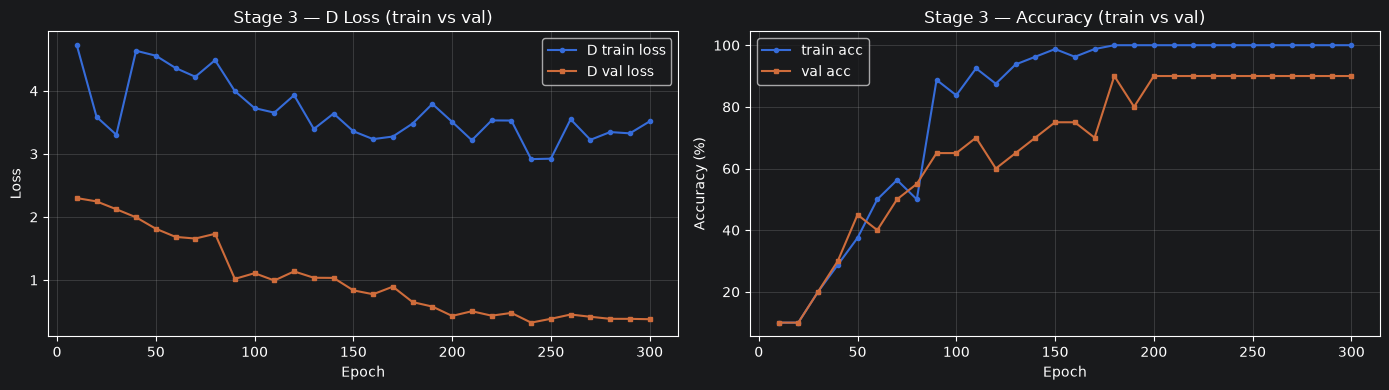

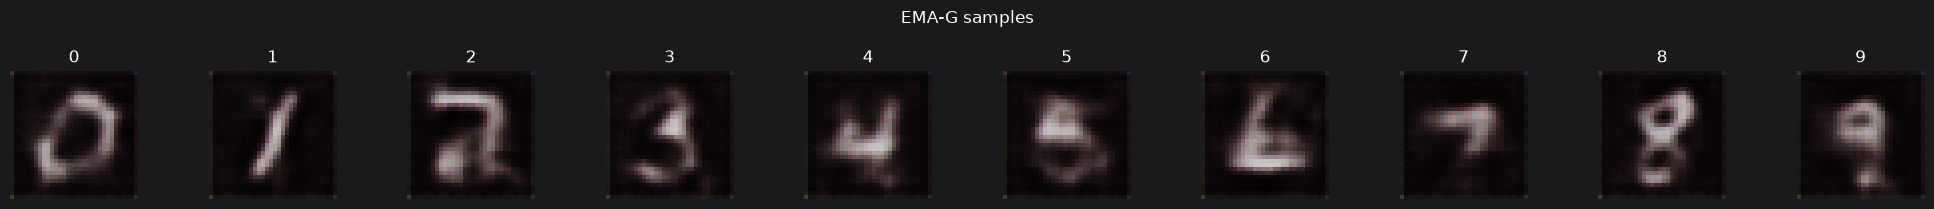

In [11]:
def tta_predict(model, x, n_views=5):
    """
    TTA: 複数 augmentation で予測を平均。
    lambda の closure バグ回避のため関数リストを明示的に定義。
    """
    model.eval()
    def _identity(x):  return x
    def _weak(x):      return weak_aug(x)
    def _strong(x):    return diff_augment(x)
    def _both(x):      return diff_augment(weak_aug(x))
    def _strong2(x):   return diff_augment(x)
    aug_fns = [_identity, _weak, _strong, _both, _strong2]
    probs = []
    with torch.no_grad():
        for fn in aug_fns[:n_views]:
            xv = fn(x.to(DEVICE))
            probs.append(F.softmax(model(xv)[:, :cfg.n_classes], dim=-1))
    return torch.stack(probs).mean(0)

def evaluate_test(model, test_imgs, test_lbls, batch=256, label=""):
    preds = []
    for i in tqdm(range(0, len(test_imgs), batch), desc=f"TTA [{label}]", position=0, leave=True):
        preds.append(tta_predict(model, test_imgs[i:i+batch]).argmax(1).cpu())
    preds = torch.cat(preds)
    acc   = (preds == test_lbls).float().mean().item()
    print(f"[{label}] ★ TEST Accuracy (final): {acc*100:.2f}%")
    return acc

print("\n=== Final Test Evaluation (1回のみ) ===")
if history:
    best_ep = max(history, key=lambda h: h[5])
    print(f"  Best val_acc: {best_ep[5]*100:.1f}%  @ epoch {best_ep[0]}")
evaluate_test(D,     test_imgs, test_lbls, label="D (no SWA)")
evaluate_test(D_swa, test_imgs, test_lbls, label="D_swa")

# 学習曲線プロット (4指標)
try:
    import matplotlib.pyplot as plt
    if history:
        eps        = [h[0] for h in history]
        d_trains   = [h[1] for h in history]
        d_vals     = [h[2] for h in history]
        train_accs = [h[4]*100 for h in history]
        val_accs   = [h[5]*100 for h in history]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(eps, d_trains, label="D train loss", marker="o", ms=3)
        axes[0].plot(eps, d_vals,   label="D val loss",   marker="s", ms=3)
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Stage 3 — D Loss (train vs val)")
        axes[0].legend(); axes[0].grid(alpha=0.3)

        axes[1].plot(eps, train_accs, label="train acc", marker="o", ms=3)
        axes[1].plot(eps, val_accs,   label="val acc",   marker="s", ms=3)
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_title("Stage 3 — Accuracy (train vs val)")
        axes[1].legend(); axes[1].grid(alpha=0.3)

        plt.tight_layout(); plt.show()
except ImportError:
    pass

# EMA-G サンプル
G_ema.eval()
with torch.no_grad():
    gs = G_ema(torch.randn(10, cfg.latent_dim, device=DEVICE),
               torch.arange(10, device=DEVICE)).cpu()
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 10, figsize=(20, 2))
    for i, ax in enumerate(axes):
        ax.imshow(gs[i].permute(1, 2, 0).numpy(), cmap="gray")
        ax.set_title(str(i)); ax.axis("off")
    plt.suptitle("EMA-G samples", y=1.02); plt.tight_layout(); plt.show()
except ImportError:
    pass
